In [1]:
pip install pandas numpy matplotlib seaborn xgboost scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: P:\DSU College work\SEM-2\Mini project\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for data validation plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load the CSV file from your Colab environment
file_path = 'alzheimers_synthetic_10k.csv'
df = pd.read_csv(file_path)

print(f"✅ Data Loaded Successfully!")
print(f"• Total patient rows: {df.shape[0]}")
print(f"• Total tracking columns: {df.shape[1]}\n")

# Display first few rows to confirm visual structure
df.head()

✅ Data Loaded Successfully!
• Total patient rows: 10000
• Total tracking columns: 51



,patient_id,age,sex,education_years,bmi,apoe4_alleles,family_history_ad,hypertension,diabetes,smoking_history,...,insulin_uUml,cortisol_nmol,bdnf_ngml,igf1_ngml,pdgf_pgml,mmse,moca,cdr,diagnosis,diagnosis_code
0,AD00001,53,M,13,26.3,0,0,0,0,Former,...,7.66,437.8,22.39,72.0,5926,29,28,0.0,CN,0
1,AD00002,76,F,11,30.3,1,0,0,1,Never,...,35.38,314.1,9.29,153.5,3902,14,17,2.0,AD,2
2,AD00003,65,M,16,17.9,2,1,0,0,Never,...,6.75,301.8,32.49,203.7,6869,25,17,0.5,MCI,1
3,AD00004,66,M,14,27.0,0,0,0,1,Never,...,14.54,553.1,26.74,264.7,5144,24,25,0.5,MCI,1
4,AD00005,74,F,16,24.5,0,0,0,0,Never,...,18.09,439.5,21.33,181.7,5910,26,25,0.0,CN,0


In [3]:
# Check for null/missing entries globally
total_nulls = df.isnull().sum().sum()
print(f"🔍 Total missing (NaN) values in dataset: {total_nulls}")

if total_nulls > 0:
    print("⚠️ Column-wise breakdown of missing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("👉 Perfect! No missing values detected.")

# Check for identical duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"🔍 Total duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    print("⚠️ Dropping duplicates to clean dataset...")
    df = df.drop_duplicates().reset_index(drop=True)
    print("👉 Duplicates removed successfully.")
else:
    print("👉 Perfect! Every row represents a unique patient entry.")

🔍 Total missing (NaN) values in dataset: 0
👉 Perfect! No missing values detected.
🔍 Total duplicate rows found: 0
👉 Perfect! Every row represents a unique patient entry.


In [4]:
print("🔄 Optimizing column data types...\n")

# 1. Convert standard text variables into structured categories
nominal_columns = ['sex', 'smoking_history', 'diagnosis']
for col in nominal_columns:
    df[col] = df[col].astype('category')
    print(f"• Converted '{col}' into a Category. Unique elements: {list(df[col].unique())}")

# 2. Enforce strict sequential order on physical activity text string
activity_order = ['Sedentary', 'Light', 'Moderate', 'Active']
df['physical_activity'] = pd.Categorical(df['physical_activity'], categories=activity_order, ordered=True)
print(f"• Converted 'physical_activity' into a sorted Ordinal Category.\n")

print("✅ Column optimizations complete. Reviewing final data architecture:")
df.info()

🔄 Optimizing column data types...

• Converted 'sex' into a Category. Unique elements: ['M', 'F']
• Converted 'smoking_history' into a Category. Unique elements: ['Former', 'Never', 'Current']
• Converted 'diagnosis' into a Category. Unique elements: ['CN', 'AD', 'MCI']
• Converted 'physical_activity' into a sorted Ordinal Category.

✅ Column optimizations complete. Reviewing final data architecture:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   patient_id          10000 non-null  str     
 1   age                 10000 non-null  int64   
 2   sex                 10000 non-null  category
 3   education_years     10000 non-null  int64   
 4   bmi                 10000 non-null  float64 
 5   apoe4_alleles       10000 non-null  int64   
 6   family_history_ad   10000 non-null  int64   
 7   hypertension        10000 non-null  int64   

In [5]:
# Filter and show boundaries for critical demographic and cognitive metrics
vital_checks = ['age', 'education_years', 'bmi', 'mmse', 'moca', 'cdr']
print("📊 Data Range & Boundary Verification:")
display(df[vital_checks].describe().T[['min', 'max', 'mean']])

# Check the distribution alignment between categorical text diagnosis and numerical code
print("\n📋 Checking label encoding harmony:")
print(df.groupby(['diagnosis', 'diagnosis_code'], observed=False).size().reset_index(name='patient_count'))

📊 Data Range & Boundary Verification:


,min,max,mean
age,50.0,95.0,69.80170
education_years,6.0,22.0,13.97670
bmi,16.0,43.7,26.55607
mmse,5.0,30.0,25.23030
moca,0.0,30.0,22.82960
cdr,0.0,3.0,0.56830



📋 Checking label encoding harmony:
  diagnosis  diagnosis_code  patient_count
0        AD               0              0
1        AD               1              0
2        AD               2           2413
3        CN               0           4582
4        CN               1              0
5        CN               2              0
6       MCI               0              0
7       MCI               1           3005
8       MCI               2              0


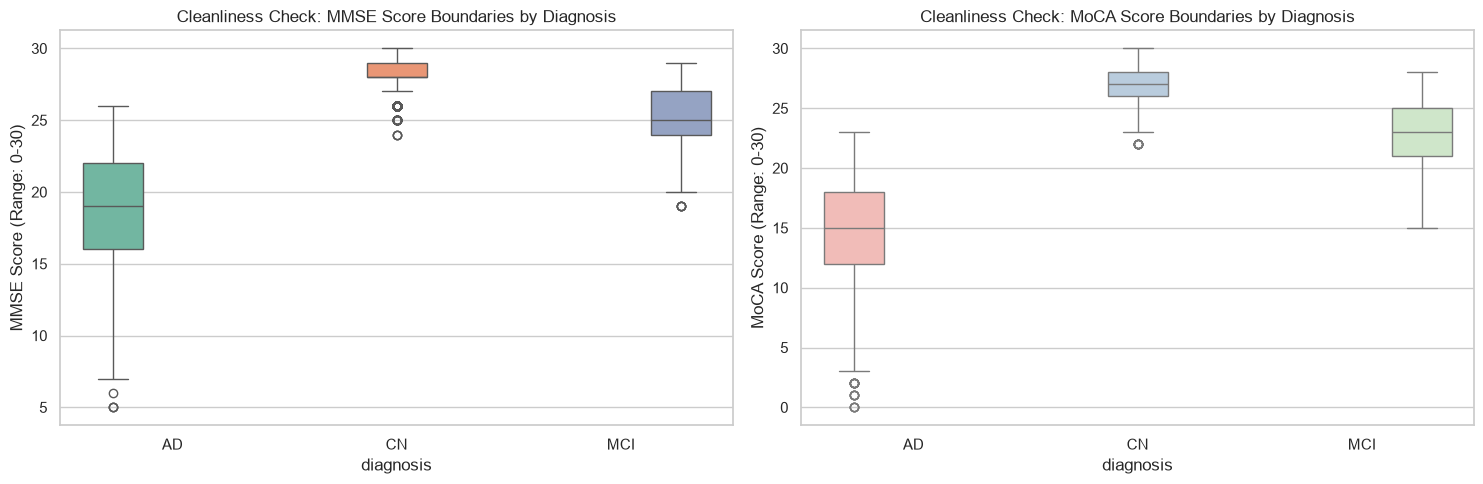


🎉 Everything is validated! Your data is clean, structurally sound, and ready for exploration.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot MMSE distributions across clinical stages
sns.boxplot(ax=axes[0], x='diagnosis', y='mmse', data=df, palette='Set2', hue='diagnosis', legend=False)
axes[0].set_title('Cleanliness Check: MMSE Score Boundaries by Diagnosis')
axes[0].set_ylabel('MMSE Score (Range: 0-30)')

# Plot MoCA distributions across clinical stages
sns.boxplot(ax=axes[1], x='diagnosis', y='moca', data=df, palette='Pastel1', hue='diagnosis', legend=False)
axes[1].set_title('Cleanliness Check: MoCA Score Boundaries by Diagnosis')
axes[1].set_ylabel('MoCA Score (Range: 0-30)')

plt.tight_layout()
plt.show()

print("\n🎉 Everything is validated! Your data is clean, structurally sound, and ready for exploration.")

In [7]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
# Exclude target, duplicate target, and patient identifier
feature_cols = ['ptau181_pgml', 'ptau217_pgml', 'ab42_ab40_ratio', 'nfl_pgml', 'gfap_pgml']

X = df[feature_cols]
y = df['diagnosis_code']

# Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Features and Target prepared.")
print(f"• Train set shape: {X_train.shape}")
print(f"• Test set shape: {X_test.shape}")

✅ Features and Target prepared.
• Train set shape: (8000, 5)
• Test set shape: (2000, 5)


In [8]:
import xgboost as xgb

# Initialize XGBoost Classifier with built-in support for categorical features
# XGBoost natively handles 'sex', 'smoking_history', and 'physical_activity' (category type)
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    enable_categorical=True,
    device='cuda',
    random_state=42
)

print("🚀 Training XGBoost Classifier...")
xgb_model.fit(X_train, y_train)
print("✅ Training Complete!")

🚀 Training XGBoost Classifier...


✅ Training Complete!


📊 XGBoost Test Accuracy: 97.45%

📋 Classification Report:
              precision    recall  f1-score   support

          CN       0.98      0.98      0.98       916
         MCI       0.96      0.95      0.96       601
          AD       0.98      0.98      0.98       483

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



P:\DSU College work\SEM-2\Mini project\.venv\Lib\site-packages\xgboost\core.py:553: UserWarning: [01:18:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


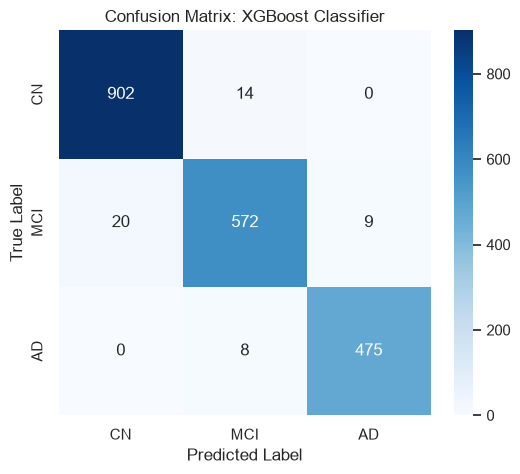

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate on test set
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"📊 XGBoost Test Accuracy: {accuracy * 100:.2f}%\n")
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['CN', 'MCI', 'AD']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['CN', 'MCI', 'AD'], yticklabels=['CN', 'MCI', 'AD'])
plt.title('Confusion Matrix: XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

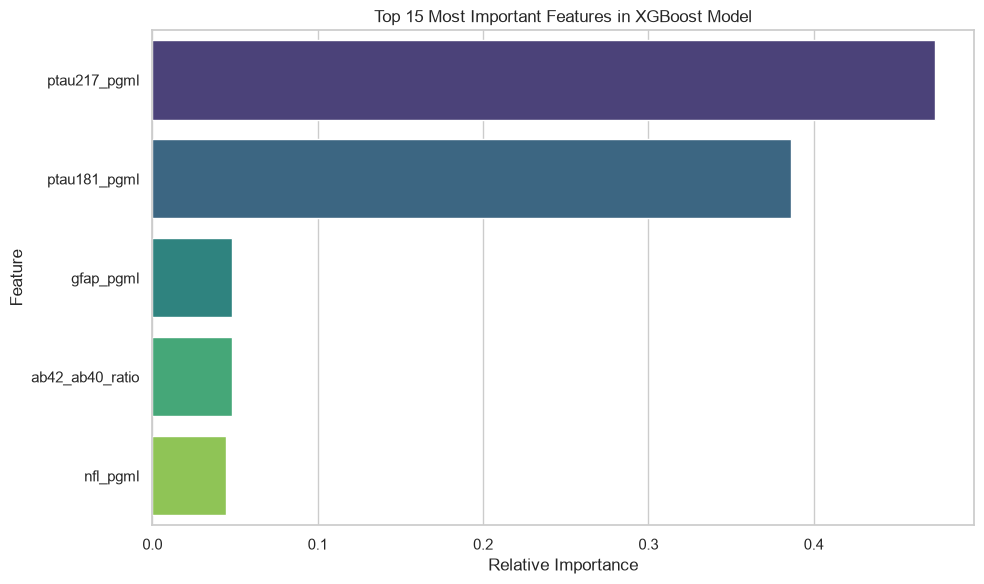

In [10]:
# Extract and plot feature importances
importances = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features in XGBoost Model')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [11]:
# --- LOGISTIC REGRESSION TRAINING & PARAMETER EXTRACTION ---
# This cell trains the Logistic Regression model on the 5 core blood biomarkers
# and outputs the mean, scale, intercept, and coefficients used in the frontend application.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Mean:', [round(x, 4) for x in scaler.mean_])
print('Scale:', [round(x, 4) for x in scaler.scale_])

# Fit Logistic Regression
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = lr.predict(X_test_scaled)
print(f'Logistic Regression Test Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%\n')
print(classification_report(y_test, y_pred_lr, target_names=['CN', 'MCI', 'AD']))

print('Intercept:', [round(x, 4) for x in lr.intercept_])
print('Coefficients:')
for idx, coef in enumerate(lr.coef_):
    print(f'Class {idx}: {[round(x, 4) for x in coef]}')


Mean: [np.float64(3.1165), np.float64(0.3734), np.float64(0.073), np.float64(23.1955), np.float64(175.5962)]
Scale: [np.float64(1.688), np.float64(0.2257), np.float64(0.0225), np.float64(12.0721), np.float64(78.0776)]
Logistic Regression Test Accuracy: 97.60%

              precision    recall  f1-score   support

          CN       0.98      0.99      0.98       916
         MCI       0.96      0.96      0.96       601
          AD       0.98      0.98      0.98       483

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000

Intercept: [np.float64(-1.6748), np.float64(4.9186), np.float64(-3.2439)]
Coefficients:
Class 0: [np.float64(-4.3432), np.float64(-5.1167), np.float64(2.3452), np.float64(-2.0057), np.float64(-2.3417)]
Class 1: [np.float64(0.5176), np.float64(0.7286), np.float64(0.1081), np.float64(0.2125), np.float64(0.2227)]
Class 2: [np.float64(3.8256), np.float64(4.388